In [30]:
from datetime import datetime
import requests
from requests.auth import HTTPBasicAuth

token = 'ATATT3xFfGF0KGqUVFWB39fP8yqR-vkIG27a191l_YXHrpXg6OiM7KDdkx_vlBjsFZl2B0s_3WUJK3YA2eiWREyTYiURQOTuDlSt_hITPkXlQ1PKuxleTqwNuonEIsJks0ysgzBc9SmJQR0Vc00H7kkWFEx_8RboQhXtWDd9FzK10us2-rMRh-0=B508BBB1'

JIRA_BASE_URL = 'https://paymentsense.atlassian.net'
JIRA_BOARD_ID = 'HS-2403'
JIRA_USERNAME = 'alex.malafeev@dojo.tech'
JIRA_API_TOKEN = token

def list_fields():
    response = requests.get(f'{JIRA_BASE_URL}/rest/api/latest/field', auth=HTTPBasicAuth(JIRA_USERNAME, JIRA_API_TOKEN))
    response.raise_for_status()
    fields = response.json()
    print('Fields:', fields)


def search(jql: str):
    url = f'{JIRA_BASE_URL}/rest/api/latest/search'

    #  "jql": "project = HS AND status = 'Done' AND resolved >= -2w",
    # "jql": "project = HS AND status = 'Done' AND  issuetype = 'Bug' AND resolved >= -2w",
    body = {
    "jql": jql,
    "startAt": 0,
    "maxResults": 50,
    "fields": [
        "summary",
        "status",
        "issuetype",
        "project",
        "assignee",
        "creator",
        "changelog"
    ]
    }

    try:
        response = requests.post(url, json=body, auth=HTTPBasicAuth(JIRA_USERNAME, JIRA_API_TOKEN))

        # response = requests.get(url, auth=HTTPBasicAuth(JIRA_USERNAME, JIRA_API_TOKEN))
        response.raise_for_status()
        issues = response.json().get('issues', [])

        return issues
    except requests.exceptions.RequestException as e:
        print('Error fetching issues:', e)


def get_issue(issue_key: str):
    url = f'{JIRA_BASE_URL}/rest/api/latest/issue/{issue_key}?expand=changelog'
    try:
        response = requests.get(url, auth=HTTPBasicAuth(JIRA_USERNAME, JIRA_API_TOKEN))
        response.raise_for_status()
        issue = response.json()
        return issue
    except requests.exceptions.RequestException as e:
        print('Error fetching issue:', e)

def get_status_durations(issue):
    prevDate = None
    status_map = {}
    for history in reversed(issue['changelog']['histories']):
        for item in history['items']:
            if item['field'] == 'status':
                if prevDate is not None:
                    fromDate = datetime.strptime(history['created'], "%Y-%m-%dT%H:%M:%S.%f%z")
                    difference = fromDate - prevDate
                    hours_difference = difference.total_seconds() / 3600
                    status = item['fromString']

                    status_map[status] = {"duration":hours_difference, "user": history['author']['displayName']}
                    prevDate = fromDate
                else:
                    prevDate = datetime.strptime(history['created'], "%Y-%m-%dT%H:%M:%S.%f%z")

                break
    return status_map

def build_durations_map(issues):
    issues_durations = {}
    for issue in issues:
        issueDetails = get_issue(issue['key'])
        status_map = get_status_durations(issueDetails)

        issues_durations[issue['key']] = status_map
    return issues_durations






In [57]:
import matplotlib.pyplot as plt


def plot_histogram(data, active_statuses = None):
    status_durations = {}
        # Iterate through the data to collect durations by status
    for ticket, statuses in data.items():
        for status, details in statuses.items():
            if active_statuses is not None and  status not in active_statuses:
                continue
            duration = details['duration']
            if status not in status_durations:
                status_durations[status] = []
            status_durations[status].append(round(duration / 24))

    # Plot the histogram
    plt.figure(figsize=(10, 6))
    for status, durations in status_durations.items():
        plt.hist(durations, bins=20, alpha=0.5, label=status)

    plt.xlabel('Duration (days)')
    plt.ylabel('Number of Tickets')
    plt.title('Histogram of Ticket Durations by Status')
    plt.legend(loc='upper right')
    plt.show()

def plot_histogram_by_user(data, filter_status: str = None):
    user_durations = {}
    # Iterate through the data to collect durations by user
    for ticket, statuses in data.items():
        for status, details in statuses.items():
            if status != filter_status:
                continue
            user = details['user']

            duration = details['duration']
            if user not in user_durations:
                user_durations[user] = []
            user_durations[user].append(round(duration / 24))

    # Plot the histogram
    plt.figure(figsize=(10, 6))
    for user, durations in user_durations.items():
        plt.hist(durations, bins=20, alpha=0.5, label=user)

    plt.xlabel('Duration (days)')
    plt.ylabel('Number of Tickets')
    plt.title('Histogram of Ticket Durations by User')
    plt.legend(loc='upper right')
    plt.show()

In [ ]:
vis_issues = search('project = VIS AND status = "Done" AND resolved >= -2w')
vis_issues_map = build_durations_map(vis_issues)
plot_histogram(vis_issues_map, ['In Review', 'In Progress', 'Ready for QA'])

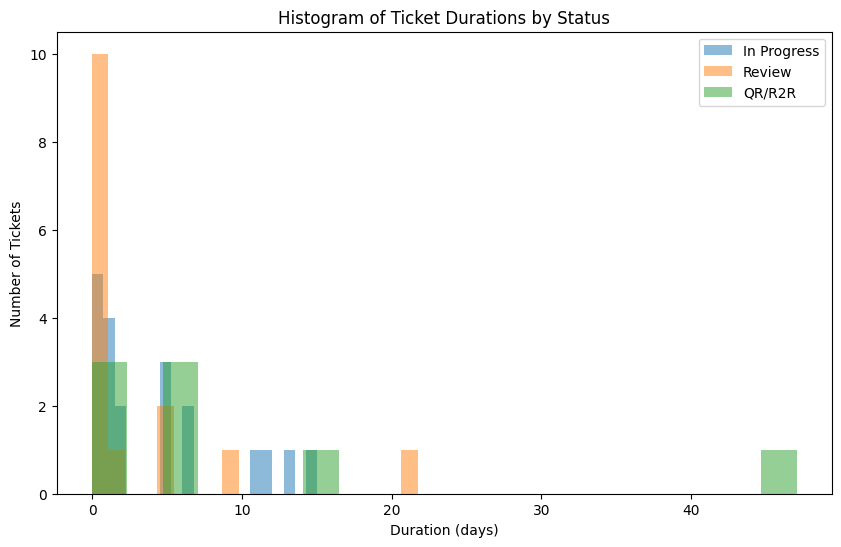

In [ ]:
hs_issues = search('project = HS AND status = "Done" AND resolved >= -2w')
hs_issues_map = build_durations_map(hs_issues)
plot_histogram(hs_issues_map, ['In Progress', 'Review', 'QR/R2R'])

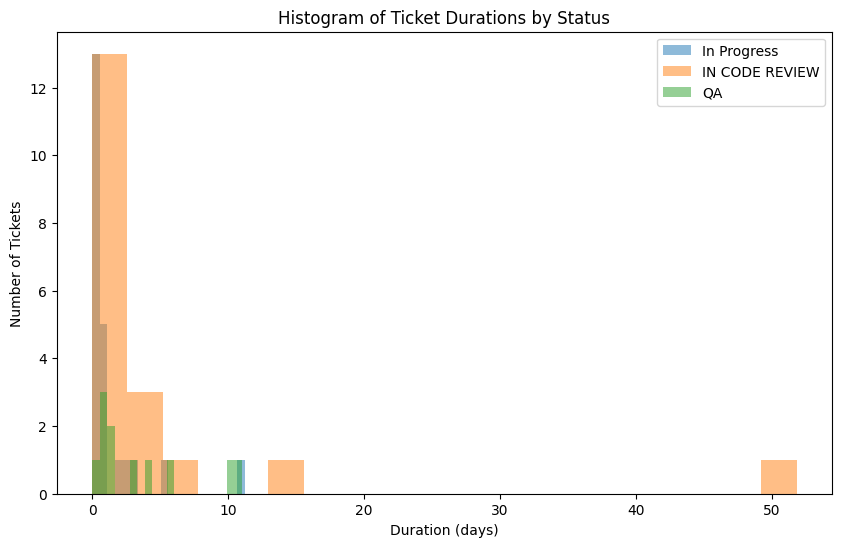

In [ ]:
cpp_issues = search('project = CPP AND status = "Done" AND resolved >= -2w')
cpp_issues_map = build_durations_map(cpp_issues)
plot_histogram(cpp_issues_map, ['In Progress', 'IN CODE REVIEW', 'QA'])

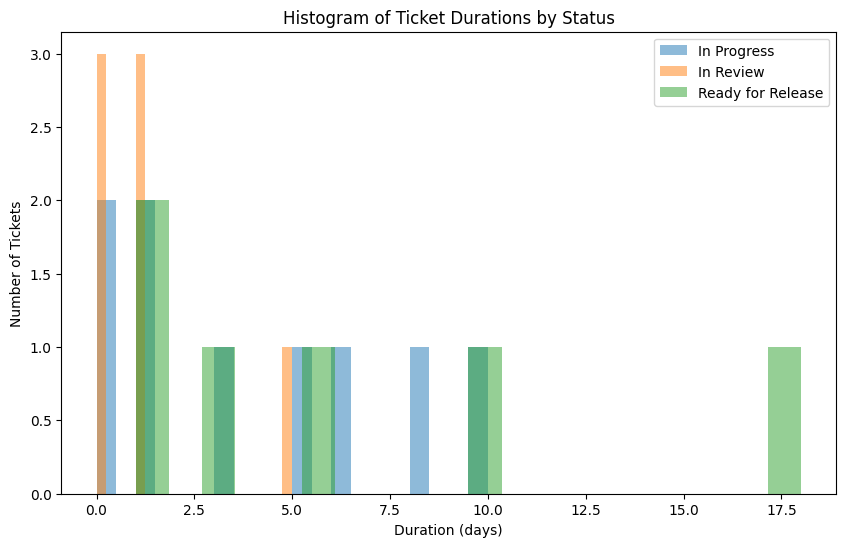

In [ ]:
con_issues = search('project = CON AND status = "Done" AND resolved >= -2w')
con_issues_map = build_durations_map(con_issues)
plot_histogram(con_issues_map, ['In Progress', 'In Review', 'Ready for Release'])

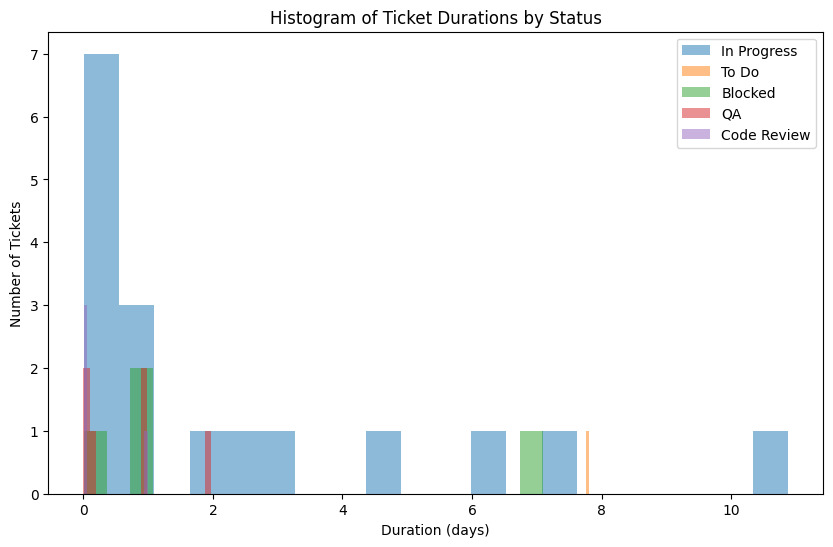

In [44]:
pppp_issues = search('project = PPPP AND status = "Done" AND resolved >= -2w')
pppp_issues_map = build_durations_map(pppp_issues)
plot_histogram(pppp_issues_map)#, ['In Progress', 'In Review', 'Ready for QA'])

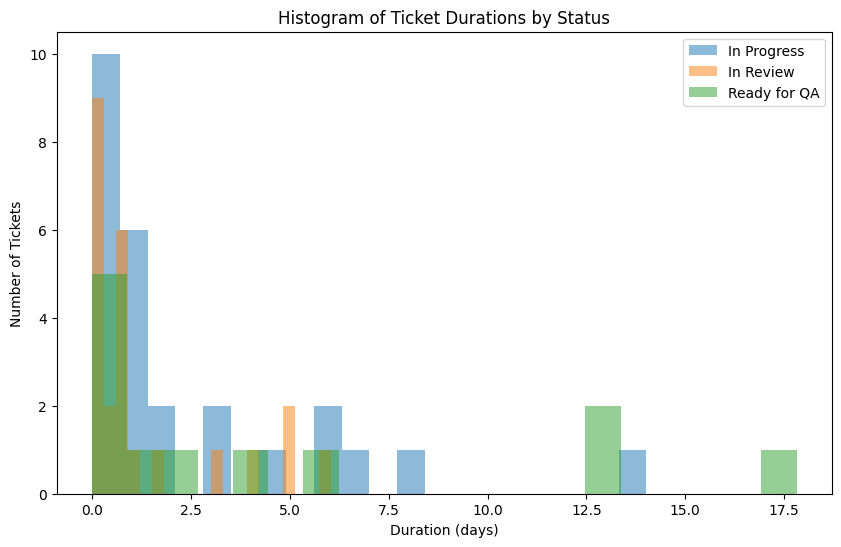

In [ ]:
vis_issues = search('project = VIS AND status = "Done" AND resolved >= -2w')
vis_issues_map = build_durations_map(vis_issues)
plot_histogram(vis_issues_map, ['In Progress', 'In Review', 'Ready for QA'])

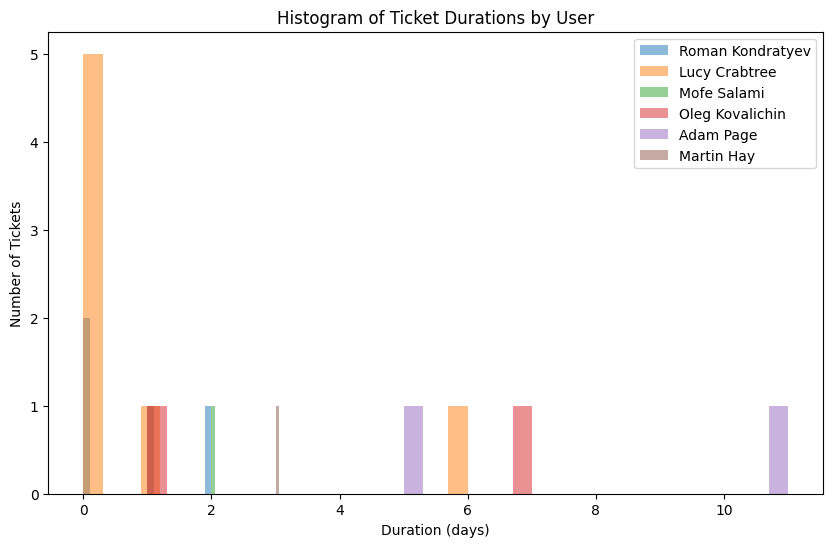

In [58]:
plot_histogram_by_user(pppp_issues_map, 'In Progress')

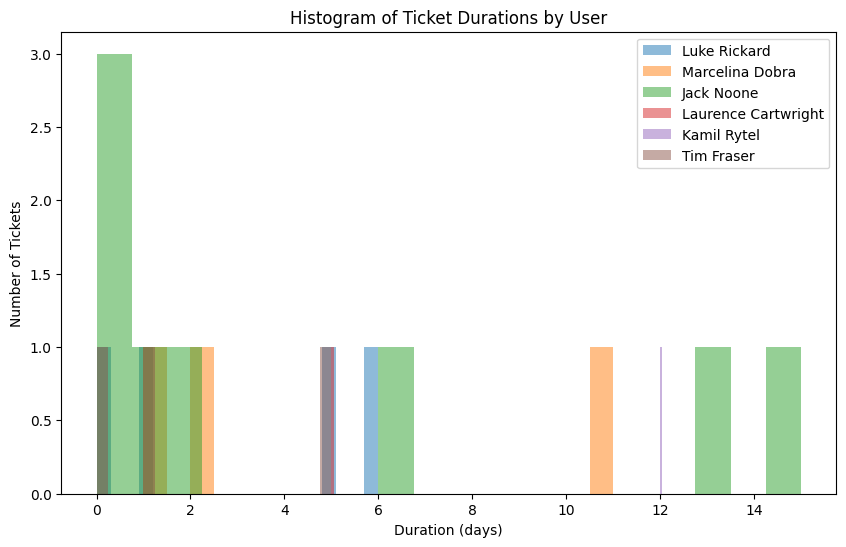

In [59]:
plot_histogram_by_user(hs_issues_map, 'In Progress')

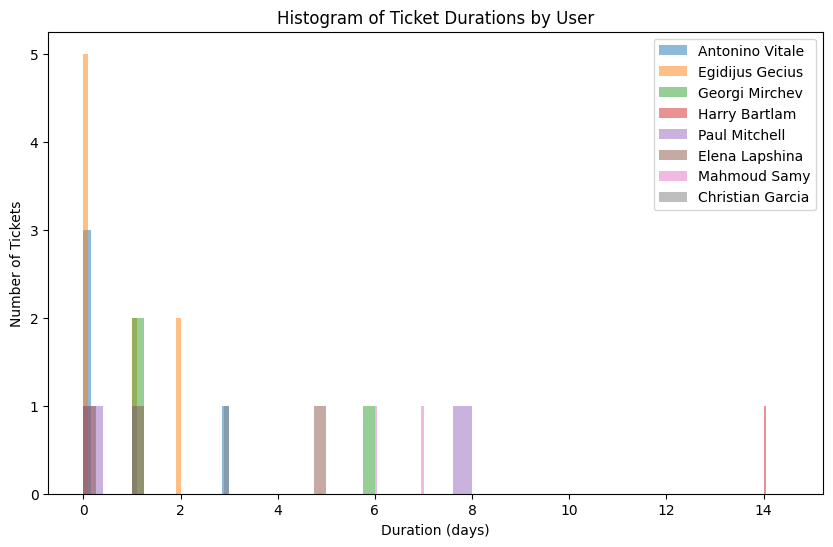

In [60]:
plot_histogram_by_user(vis_issues_map, 'In Progress')

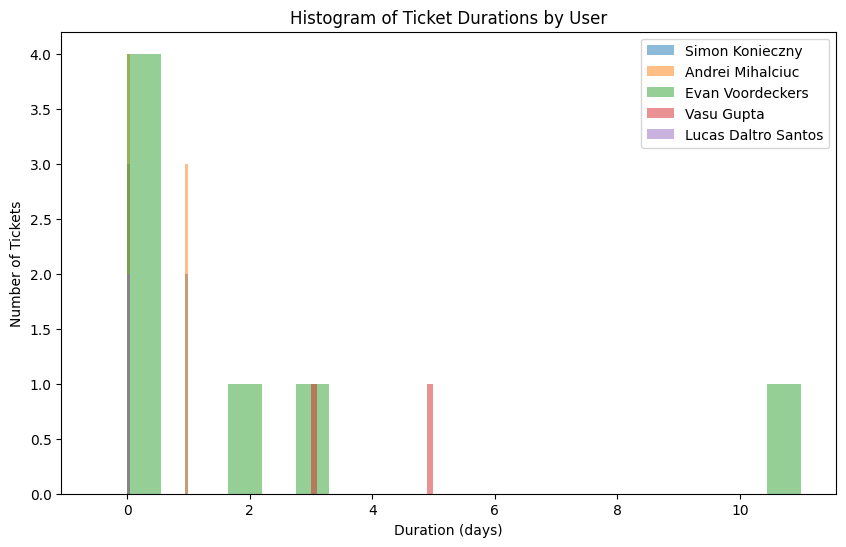

In [61]:
plot_histogram_by_user(cpp_issues_map, 'In Progress')

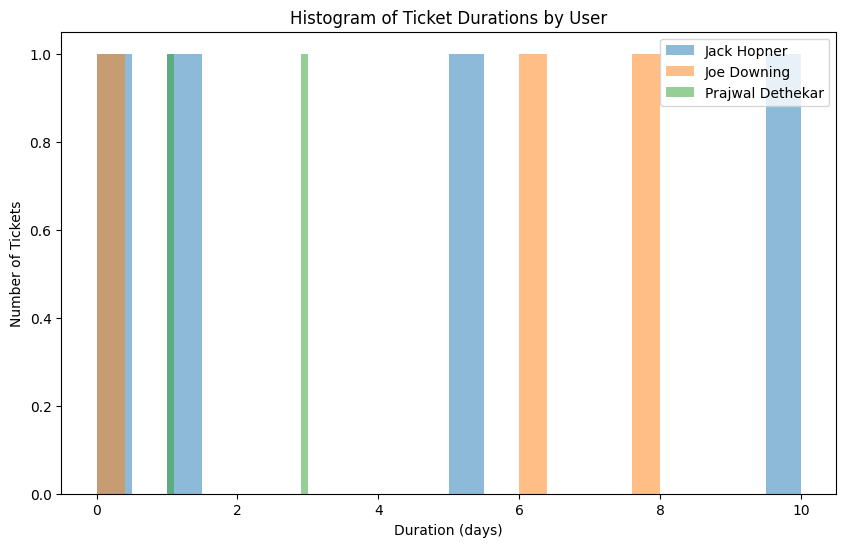

In [62]:
plot_histogram_by_user(con_issues_map, 'In Progress')